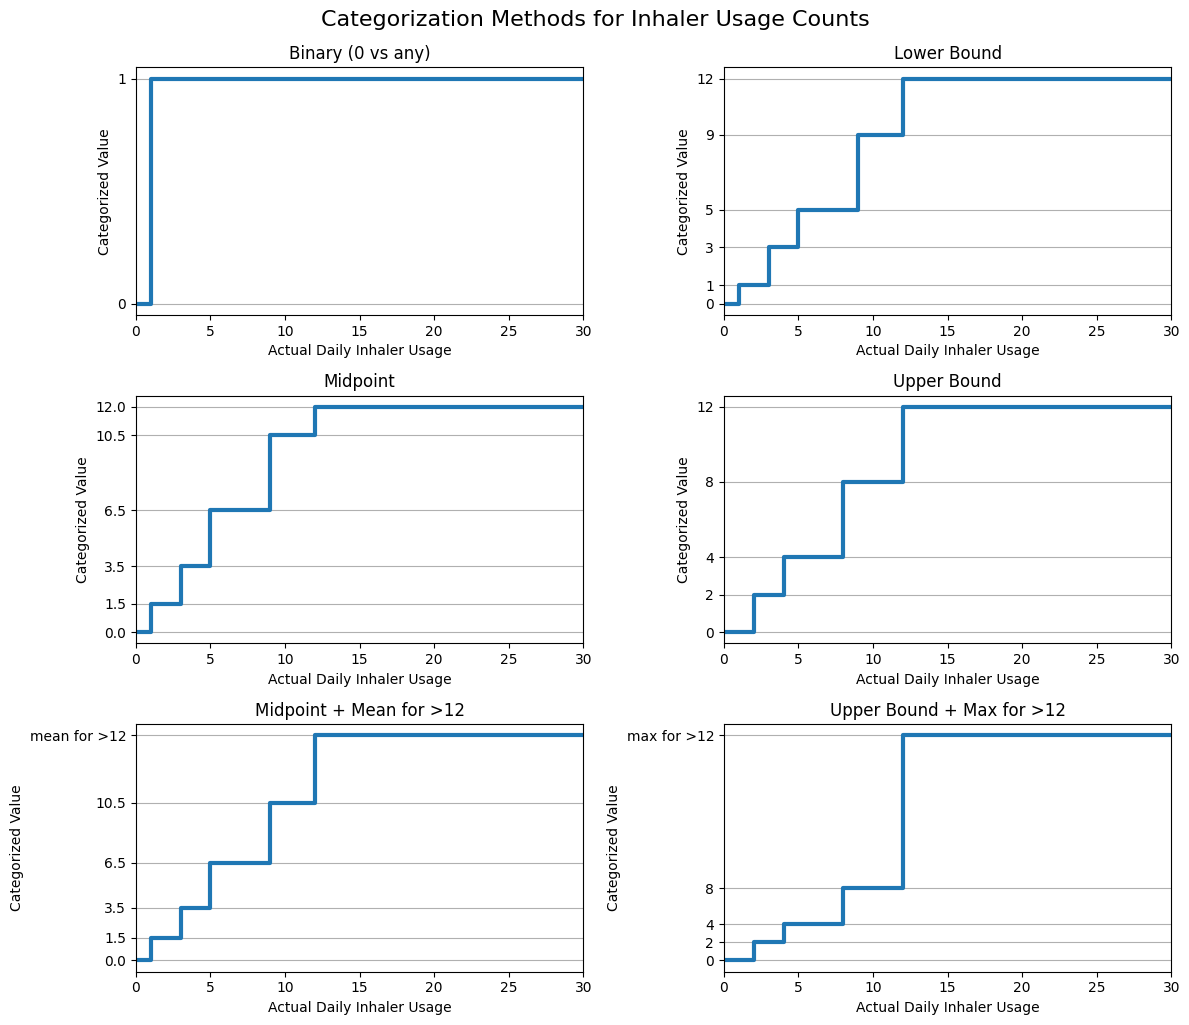

In [7]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 31)

def binary(x):  # 0 or 1
    return np.where(x == 0, 0, 1)

def lower_bound(x):
    bins = [0, 1, 3, 5, 9, 12, np.inf]
    values = [0, 1, 3, 5, 9, 12]
    return np.select([x < b for b in bins[1:]], values, default=values[-1])

def midpoint(x):
    bins = [0, 1, 3, 5, 9, 12, np.inf]
    values = [0, 1.5, 3.5, 6.5, 10.5, 12]
    return np.select([x < b for b in bins[1:]], values, default=values[-1])

def upper_bound(x):
    bins = [0, 2, 4, 8, 12, np.inf]
    values = [0, 2, 4, 8, 12]
    return np.select([x < b for b in bins[1:]], values, default=values[-1])

def midpoint_plus_mean(x, mean_gt12=15):
    bins = [0, 1, 3, 5, 9, 12, np.inf]
    values = [0, 1.5, 3.5, 6.5, 10.5, mean_gt12]
    return np.select([x < b for b in bins[1:]], values, default=mean_gt12)

def upper_bound_plus_max(x, max_gt12=25):
    bins = [0, 2, 4, 8, 12, np.inf]
    values = [0, 2, 4, 8, max_gt12]
    return np.select([x < b for b in bins[1:]], values, default=max_gt12)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

methods = [
    ("Binary (0 vs any)", binary),
    ("Lower Bound", lower_bound),
    ("Midpoint", midpoint),
    ("Upper Bound", upper_bound),
    ("Midpoint + Mean for >12", lambda x: midpoint_plus_mean(x, mean_gt12=15)),
    ("Upper Bound + Max for >12", lambda x: upper_bound_plus_max(x, max_gt12=25)),
]

for i, (ax, (title, func)) in enumerate(zip(axes, methods)):
    if title == "Midpoint + Mean for >12":
        y = midpoint_plus_mean(x, mean_gt12=15)
        unique_y = sorted(set(y))
        # Replace last tick label with "mean for >12"
        yticklabels = [str(val) for val in unique_y[:-1]] + ["mean for >12"]
    elif title == "Upper Bound + Max for >12":
        y = upper_bound_plus_max(x, max_gt12=25)
        unique_y = sorted(set(y))
        yticklabels = [str(val) for val in unique_y[:-1]] + ["max for >12"]
    else:
        y = func(x)
        unique_y = sorted(set(y))
        yticklabels = [str(val) for val in unique_y]
    ax.step(x, y, where='post', linewidth=3)
    ax.set_yticks(unique_y)
    ax.set_yticklabels(yticklabels)
    ax.set_title(title)
    ax.set_xlabel("Actual Daily Inhaler Usage")
    ax.set_ylabel("Categorized Value")
    ax.grid(True, axis='y')
    ax.set_xlim(0, 30)
    ax.set_xticks(np.arange(0, 31, 5))
    ax.set_xticklabels(np.arange(0, 31, 5))

plt.tight_layout()
plt.suptitle("Categorization Methods for Inhaler Usage Counts", y=1.02, fontsize=16)
plt.show()

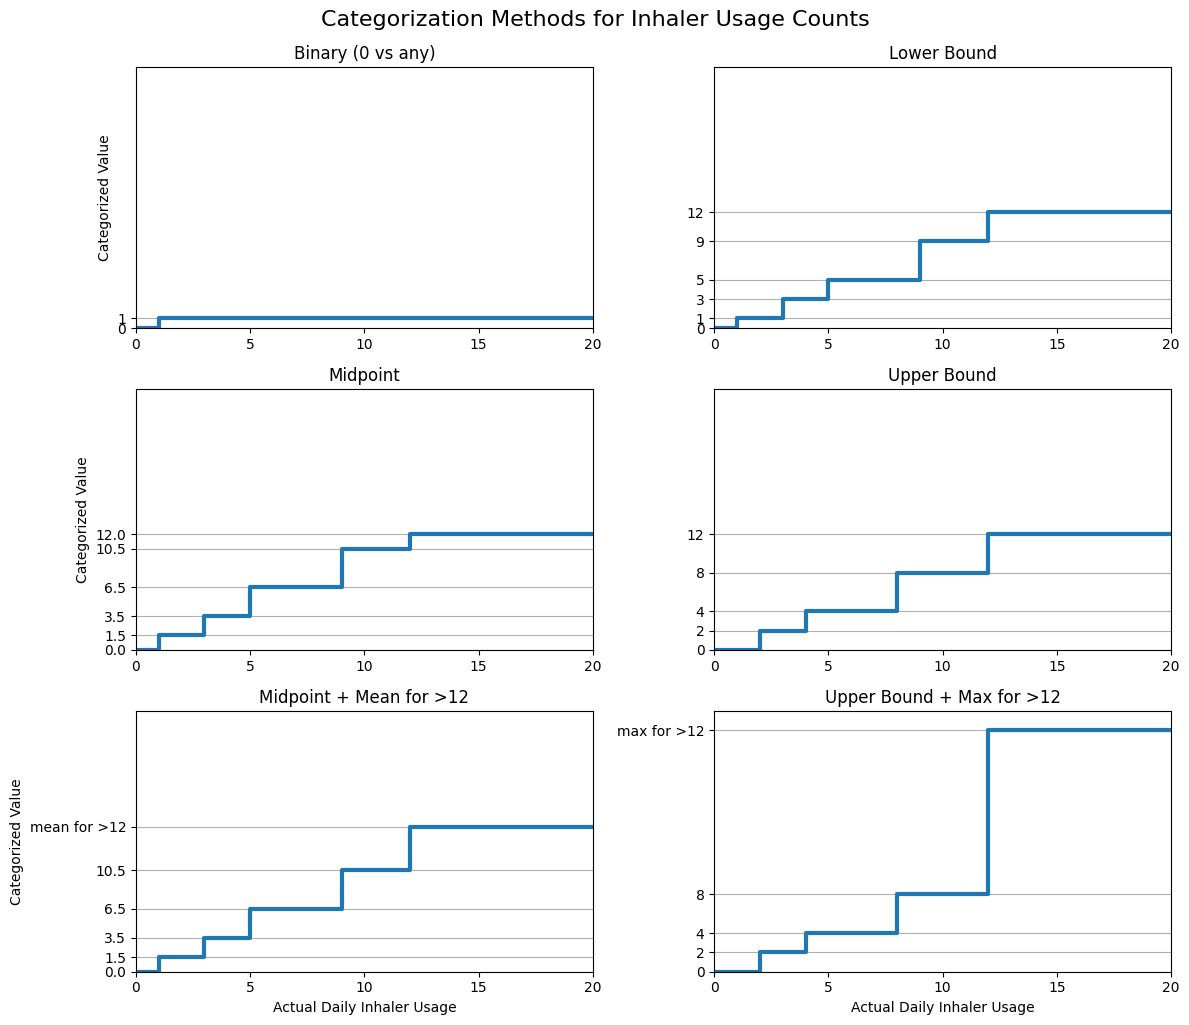

In [21]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0, 31)

def binary(x):  # 0 or 1
    return np.where(x == 0, 0, 1)

def lower_bound(x):
    bins = [0, 1, 3, 5, 9, 12, np.inf]
    values = [0, 1, 3, 5, 9, 12]
    return np.select([x < b for b in bins[1:]], values, default=values[-1])

def midpoint(x):
    bins = [0, 1, 3, 5, 9, 12, np.inf]
    values = [0, 1.5, 3.5, 6.5, 10.5, 12]
    return np.select([x < b for b in bins[1:]], values, default=values[-1])

def upper_bound(x):
    bins = [0, 2, 4, 8, 12, np.inf]
    values = [0, 2, 4, 8, 12]
    return np.select([x < b for b in bins[1:]], values, default=values[-1])

def midpoint_plus_mean(x, mean_gt12=15):
    bins = [0, 1, 3, 5, 9, 12, np.inf]
    values = [0, 1.5, 3.5, 6.5, 10.5, mean_gt12]
    return np.select([x < b for b in bins[1:]], values, default=mean_gt12)

def upper_bound_plus_max(x, max_gt12=25):
    bins = [0, 2, 4, 8, 12, np.inf]
    values = [0, 2, 4, 8, max_gt12]
    return np.select([x < b for b in bins[1:]], values, default=max_gt12)

max_gt12 = 25  # Value for "max for >12"
y_buffer = 2   # Extra space above the max value
n_rows, n_cols = 3, 2

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

methods = [
    ("Binary (0 vs any)", binary),
    ("Lower Bound", lower_bound),
    ("Midpoint", midpoint),
    ("Upper Bound", upper_bound),
    ("Midpoint + Mean for >12", lambda x: midpoint_plus_mean(x, mean_gt12=15)),
    ("Upper Bound + Max for >12", lambda x: upper_bound_plus_max(x, max_gt12=max_gt12)),
]

for i, (ax, (title, func)) in enumerate(zip(axes, methods)):
    row = i // n_cols
    col = i % n_cols
    
    if title == "Midpoint + Mean for >12":
        y = midpoint_plus_mean(x, mean_gt12=15)
        unique_y = sorted(set(y))
        yticklabels = [str(val) for val in unique_y[:-1]] + ["mean for >12"]
    elif title == "Upper Bound + Max for >12":
        y = upper_bound_plus_max(x, max_gt12=max_gt12)
        unique_y = sorted(set(y))
        yticklabels = [str(val) for val in unique_y[:-1]] + ["max for >12"]
    else:
        y = func(x)
        unique_y = sorted(set(y))
        yticklabels = [str(val) for val in unique_y]
    ax.step(x, y, where='post', linewidth=3)
    ax.set_yticks(unique_y)
    ax.set_yticklabels(yticklabels)
    ax.set_title(title)
    if row == n_rows - 1:
        ax.set_xlabel("Actual Daily Inhaler Usage")
    if col == 0:
        ax.set_ylabel("Categorized Value")
    ax.grid(True, axis='y')
    ax.set_xlim(0, 20)
    ax.set_xticks(np.arange(0, 21, 5))
    ax.set_xticklabels(np.arange(0, 21, 5))
    ax.set_ylim(0, max_gt12 + y_buffer)  # Add buffer above max

plt.tight_layout()
plt.suptitle("Categorization Methods for Inhaler Usage Counts", y=1.02, fontsize=16)
plt.show()

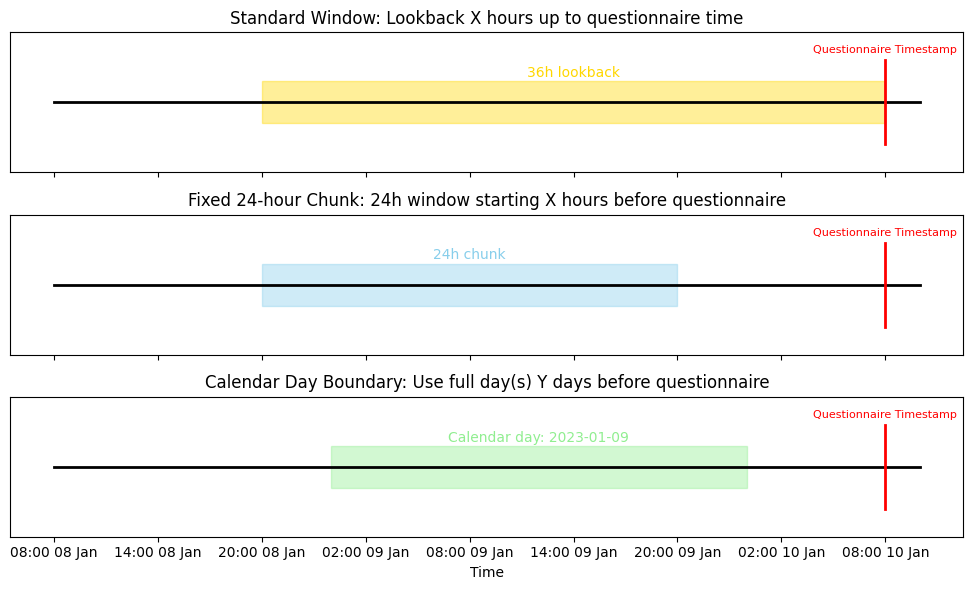

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.dates as mdates
import numpy as np
import datetime

# Example: Questionnaire at 2023-01-10 08:00
q_time = datetime.datetime(2023, 1, 10, 8, 0)
lookback_hours = 36
calendar_days_back = lookback_hours // 24  # 1

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

def plot_timeline(ax, start, end, highlight_start, highlight_end, label, color, q_time):
    # Convert datetimes to matplotlib float format
    start_num = mdates.date2num(start)
    end_num = mdates.date2num(end)
    highlight_start_num = mdates.date2num(highlight_start)
    highlight_end_num = mdates.date2num(highlight_end)
    q_time_num = mdates.date2num(q_time)
    # Timeline
    ax.plot([start_num, end_num], [0, 0], color='black', lw=2)
    # Highlighted window
    ax.add_patch(patches.Rectangle(
        (highlight_start_num, -0.15), highlight_end_num - highlight_start_num, 0.3,
        color=color, alpha=0.4
    ))
    # Questionnaire time
    ax.plot([q_time_num, q_time_num], [-0.3, 0.3], color='red', lw=2)
    ax.text(q_time_num, 0.35, "Questionnaire Timestamp", color='red', ha='center', fontsize=8)
    # Label
    midpoint = highlight_start_num + (highlight_end_num - highlight_start_num) / 2
    ax.text(midpoint, 0.18, label, ha='center', fontsize=10, color=color)
    ax.set_yticks([])
    ax.set_ylim(-0.5, 0.5)
    ax.grid(False)
    ax.xaxis_date()

# 1. Standard window (lookback)
start = q_time - datetime.timedelta(hours=48)
end = q_time + datetime.timedelta(hours=2)
highlight_start = q_time - datetime.timedelta(hours=lookback_hours)
highlight_end = q_time
plot_timeline(
    axes[0], start, end,
    highlight_start=highlight_start, highlight_end=highlight_end,
    label=f"{lookback_hours}h lookback", color='gold',
    q_time=q_time
)
axes[0].set_title("Standard Window: Lookback X hours up to questionnaire time")

# 2. use_daily_max_windows (Fixed 24-hour chunk, starting X hours before questionnaire)
chunk_start = q_time - datetime.timedelta(hours=lookback_hours)
chunk_end = chunk_start + datetime.timedelta(hours=24)
plot_timeline(
    axes[1], start, end,
    highlight_start=chunk_start, highlight_end=chunk_end,
    label="24h chunk", color='skyblue',
    q_time=q_time
)
axes[1].set_title("Fixed 24-hour Chunk: 24h window starting X hours before questionnaire")

# 3. use_calendar_days (full calendar day Y days before questionnaire)
calendar_start = (q_time - datetime.timedelta(days=calendar_days_back)).replace(hour=0, minute=0)
calendar_end = calendar_start + datetime.timedelta(days=1)
plot_timeline(
    axes[2], start, end,
    highlight_start=calendar_start, highlight_end=calendar_end,
    label=f"Calendar day: {calendar_start.date()}", color='lightgreen',
    q_time=q_time
)
axes[2].set_title("Calendar Day Boundary: Use full day(s) Y days before questionnaire")

# X-axis: show dates
xticks = [start + datetime.timedelta(hours=6*i) for i in range(int((end-start).total_seconds()//(6*3600))+1)]
xtick_nums = mdates.date2num(xticks)
xticklabels = [dt.strftime('%H:%M %d %b') for dt in xticks]
plt.xticks(xtick_nums, labels=xticklabels, rotation=0)
plt.xlabel("Time")
plt.tight_layout()
plt.show()